In [1]:
!pip install --quiet pennylane pytorch-msssim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.

In [2]:
######################################################################
# 0. One-off installs  ───────────────────────────────────────────────
######################################################################
# Uncomment the next line the first time you run the notebook
# !pip install --quiet pennylane pytorch-msssim

######################################################################
# 1. Imports & helpers  ──────────────────────────────────────────────
######################################################################
import os, json, math, random, warnings, time
warnings.filterwarnings("ignore")

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
import torchvision.transforms as T
from torchvision.datasets.folder import default_loader

import pennylane as qml
from pennylane import numpy as np
from pytorch_msssim import ssim

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on", device)

def is_anomaly(path:str)->int:
    """MVTec convention: train/*/good are normal, every other sub-folder anomalous."""
    return 0 if "good" in path else 1


Running on cuda


In [3]:
######################################################################
# 2. Dataset loader  ─────────────────────────────────────────────────
######################################################################
class MVTec(Dataset):
    def __init__(self, root, phase, transform):
        self.samples  = []
        self.transform = transform
        self.classes  = sorted([d for d in os.listdir(root) if os.path.isdir(os.path.join(root,d))])
        self.cls2idx  = {c:i for i,c in enumerate(self.classes)}

        for cls in self.classes:
            p = os.path.join(root, cls, phase)
            for r,_,files in os.walk(p):
                for f in files:
                    if f.endswith(".png"):
                        path = os.path.join(r,f)
                        lbl  = is_anomaly(path)
                        self.samples.append((path, lbl, self.cls2idx[cls]))

    def __len__(self):  return len(self.samples)

    def __getitem__(self, idx):
        path,lbl,cid = self.samples[idx]
        img = default_loader(path)
        img = self.transform(img)
        return img, lbl, cid, path

In [4]:

######################################################################
# 3. Transforms, datasets & balanced loaders  ────────────────────────
######################################################################
tfm_train = T.Compose([
    T.Grayscale(),
    T.RandomHorizontalFlip(),
    T.RandomRotation(5),
    T.ColorJitter(brightness=.1, contrast=.1),
    T.Resize((64,64)),
    T.ToTensor(),
    T.Normalize([0.5],[0.5])
])

tfm_test = T.Compose([
    T.Grayscale(),
    T.Resize((64,64)),
    T.ToTensor(),
    T.Normalize([0.5],[0.5])
])

ROOT = "/kaggle/input/mvtec-ad"          # adjust if necessary
train_ds = MVTec(ROOT, "train", tfm_train)   # train split = normal only
test_ds  = MVTec(ROOT, "test",  tfm_test)

BATCH = 32
NUM_CL = len(train_ds.classes)

# -------- class-balanced sampler ------------------------------------
from collections import defaultdict
class BalancedBatchSampler(Sampler):
    """Round-robin so each batch sees different classes."""
    def __init__(self, ds, batch_size):
        self.cls2idx = defaultdict(list)
        for idx, (_,_,cid,_) in enumerate(ds):
            self.cls2idx[cid].append(idx)
        self.batch  = batch_size
        self.classes = list(self.cls2idx.keys())
        self.length  = math.ceil(len(ds)/batch_size)

    def __iter__(self):
        ptr = {c:0 for c in self.classes}
        for _ in range(self.length):
            batch=[]
            random.shuffle(self.classes)
            for c in self.classes:
                if ptr[c] < len(self.cls2idx[c]):
                    batch.append(self.cls2idx[c][ptr[c]])
                    ptr[c]+=1
                if len(batch)==self.batch:
                    break
            yield batch

    def __len__(self): return self.length

train_loader = DataLoader(
    train_ds, batch_sampler=BalancedBatchSampler(train_ds,BATCH),
    num_workers=4, pin_memory=True)

test_loader  = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=4)

print(f"{len(train_ds)=}, {len(test_ds)=}, {NUM_CL=}")

len(train_ds)=3629, len(test_ds)=1725, NUM_CL=15


In [5]:
######################################################################
# 4. Quantum decoder building block  ─────────────────────────────────
######################################################################
N_QUBITS = 6
dev = qml.device("default.qubit", wires=N_QUBITS)

def circuit_in_dim(_):                # Pennylane helper
    return {"weights": (3, N_QUBITS, 3)}

@qml.qnode(dev, interface="torch")
def q_circuit(inputs, weights):
    qml.templates.AngleEmbedding(inputs, wires=range(N_QUBITS))
    qml.templates.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

In [6]:
######################################################################
# 5. VAE with Quantum Decoder  ───────────────────────────────────────
######################################################################
LATENT  = 16
EMB_DIM = 32

class VAE_Q(nn.Module):
    def __init__(self, stacked_q=False):
        super().__init__()
        # ----- Encoder -----
        self.enc = nn.Sequential(
            nn.Conv2d(1,  32,4,2,1), nn.ReLU(),
            nn.Conv2d(32, 64,4,2,1), nn.ReLU(),
            nn.Conv2d(64,128,4,2,1), nn.ReLU(),
            nn.Conv2d(128,256,4,2,1), nn.ReLU()   # extra depth
        )
        self.mu     = nn.Linear(256*4*4, LATENT)
        self.logvar = nn.Linear(256*4*4, LATENT)

        # ----- Decoder -----
        self.class_emb = nn.Embedding(NUM_CL, EMB_DIM)
        self.pre_fc    = nn.Sequential(
            nn.Linear(LATENT+EMB_DIM, 32), nn.ReLU(),
            nn.Linear(32, N_QUBITS)             # angles for AngleEmbedding
        )

        if stacked_q:
            self.q_layers = nn.Sequential(
                qml.qnn.TorchLayer(q_circuit, circuit_in_dim(LATENT+EMB_DIM)),
                qml.qnn.TorchLayer(q_circuit, circuit_in_dim(N_QUBITS))
            )
            q_out = N_QUBITS            # still returns #qubits exp-vals
        else:
            self.q_layers = qml.qnn.TorchLayer(q_circuit, circuit_in_dim(LATENT+EMB_DIM))
            q_out = N_QUBITS

        self.post_fc = nn.Sequential(
            nn.Linear(q_out, 512), nn.ReLU(),
            nn.Linear(512, 64*64), nn.Tanh()
        )

    # ---- plumbing ----
    def encode(self, x):
        h = self.enc(x).view(x.size(0), -1)
        return self.mu(h), self.logvar(h)

    def reparam(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z, cid):
        c  = self.class_emb(cid)
        x  = torch.cat([z,c], dim=1)
        x  = self.pre_fc(x)
        x  = self.q_layers(x)
        x  = self.post_fc(x)
        return x.view(-1,1,64,64)

    def forward(self, x, cid):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        recon = self.decode(z, cid)
        return recon, mu, logvar


In [7]:
######################################################################
# 6. Loss, model, optimiser, scheduler  ──────────────────────────────
######################################################################
def beta_schedule(epoch, cycle_len=4, max_beta=1.0):
    """Half-cosine cyclical β."""
    pos = (epoch % cycle_len) / cycle_len
    return max_beta * (1 - math.cos(pos*math.pi)) / 2

def vae_loss(recon, x, mu, logvar, epoch):
    mse   = F.mse_loss(recon, x, reduction="mean")
    ssim_ = 1 - ssim(recon, x, data_range=2, size_average=True)
    recon_l = 0.4*mse + 0.6*ssim_
    kld = -0.5*torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    beta = beta_schedule(epoch)
    return recon_l + beta*kld, recon_l, kld

model = VAE_Q(stacked_q=False).to(device)

opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=20, eta_min=1e-5)
scaler = torch.cuda.amp.GradScaler()


In [8]:
######################################################################
# 7. Training loop WITH live test accuracy  ──────────────────────────
######################################################################
EPOCHS = 20
history = {"loss":[], "recon":[], "kld":[], "acc":[]}
best_acc = 0; patience = 5; bad_epochs = 0

for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    model.train()
    l_tot=r_tot=k_tot=0.0

    for x,_,cid,_ in train_loader:
        x, cid = x.to(device), cid.to(device)

        with torch.cuda.amp.autocast():
            recon, mu, logvar = model(x, cid)
            loss, recon_l, kld_l = vae_loss(recon, x, mu, logvar, epoch)

        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt); scaler.update()
        opt.zero_grad()

        bs = x.size(0)
        l_tot += loss.item()*bs
        r_tot += recon_l.item()*bs
        k_tot += kld_l.item()*bs

    sch.step()
    N = len(train_loader.dataset)
    history["loss"].append(l_tot/N); history["recon"].append(r_tot/N); history["kld"].append(k_tot/N)

    # ------------- quick anomaly eval every epoch -------------------
    model.eval()
    scores, gt = [], []
    cls_scores = {i:[] for i in range(NUM_CL)}
    with torch.no_grad():
        # collect normal scores for thresholds
        for x,_,cid,_ in train_loader:
            x, cid = x.to(device), cid.to(device)
            recon,_,_ = model(x, cid)
            batch_score = torch.mean((x-recon)**2, dim=[1,2,3])
            for s,c in zip(batch_score, cid):
                cls_scores[c.item()].append(s.item())

        # thresholds: 90-percentile (fallback)
        thresh = {c: np.percentile(v, 90) for c,v in cls_scores.items()}

        correct = 0
        for x,lbl,cid,_ in test_loader:
            x,cid = x.to(device), cid.to(device)
            recon,_,_ = model(x, cid)
            score = torch.mean((x-recon)**2).item()
            pred  = 1 if score>thresh[cid.item()] else 0
            correct += (pred==lbl.item())
            scores.append(score); gt.append(lbl.item())
    acc = correct/len(test_loader)
    history["acc"].append(acc)

    dt = time.time()-t0
    print(f"Epoch {epoch:02d}/{EPOCHS} | loss {l_tot/N:.4f} | recon {r_tot/N:.4f} | kld {k_tot/N:.4f} "
          f"| test-ACC {acc:.3f} | {dt:.1f}s")

    # ---- early stopping ----
    if acc>best_acc:
        best_acc=acc; bad_epochs=0
        torch.save(model.state_dict(), "best_vae_q.pth")
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print("Early-stopping.")
            break


Epoch 01/20 | loss 0.2456 | recon 0.2455 | kld 0.0008 | test-ACC 0.332 | 134.0s
Epoch 02/20 | loss 0.1730 | recon 0.1730 | kld 0.0000 | test-ACC 0.332 | 127.2s
Epoch 03/20 | loss 0.1588 | recon 0.1588 | kld 0.0000 | test-ACC 0.298 | 125.2s
Epoch 04/20 | loss 0.1479 | recon 0.1479 | kld 0.2437 | test-ACC 0.304 | 125.6s
Epoch 05/20 | loss 0.1424 | recon 0.1396 | kld 0.0189 | test-ACC 0.303 | 123.0s
Epoch 06/20 | loss 0.1358 | recon 0.1358 | kld 0.0000 | test-ACC 0.307 | 125.0s
Epoch 07/20 | loss 0.1343 | recon 0.1343 | kld 0.0000 | test-ACC 0.297 | 123.9s
Early-stopping.


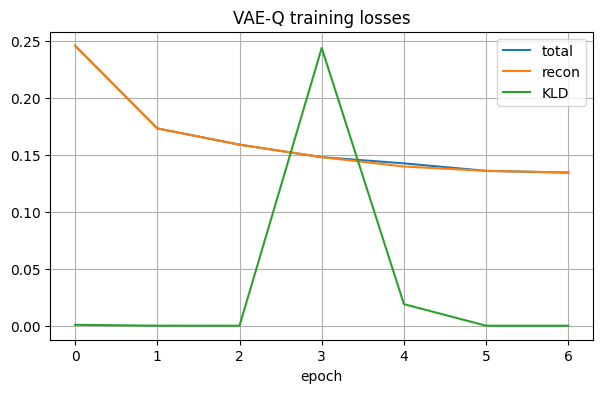

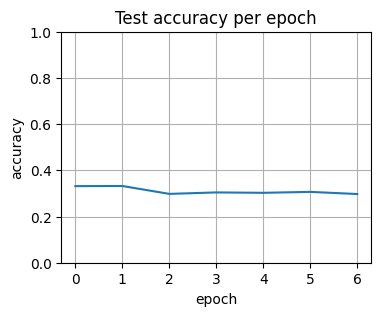

In [9]:
######################################################################
# 8. Loss & accuracy curves  ─────────────────────────────────────────
######################################################################
plt.figure(figsize=(7,4))
plt.plot(history["loss"], label="total")
plt.plot(history["recon"], label="recon")
plt.plot(history["kld"], label="KLD")
plt.title("VAE-Q training losses"); plt.xlabel("epoch"); plt.grid(); plt.legend()
plt.show()

plt.figure(figsize=(4,3))
plt.plot(history["acc"])
plt.title("Test accuracy per epoch"); plt.xlabel("epoch"); plt.ylabel("accuracy")
plt.ylim(0,1); plt.grid(); plt.show()


In [10]:
######################################################################
# 9. Final ROC-optimised thresholds  ─────────────────────────────────
######################################################################
model.load_state_dict(torch.load("best_vae_q.pth"), strict=False)
model.eval()

norm_scores = {c:[] for c in range(NUM_CL)}
anom_scores = {c:[] for c in range(NUM_CL)}   # few labelled anomalies

with torch.no_grad():
    for x,lbl,cid,_ in test_loader:
        x,cid = x.to(device), cid.to(device)
        recon,_,_ = model(x,cid)
        score = torch.mean((x-recon)**2).item()
        if lbl.item()==0: norm_scores[cid.item()].append(score)
        else:             anom_scores[cid.item()].append(score)

def roc_threshold(norm, anom):
    if len(anom)<3:                      # fallback
        return np.percentile(norm, 90)
    y = np.r_[np.zeros(len(norm)), np.ones(len(anom))]
    s = np.r_[norm, anom]
    fpr,tpr,thr = roc_curve(y,s)
    return thr[np.argmax(np.sqrt(tpr*(1-fpr)))]

THRESH = {c: roc_threshold(norm_scores[c], anom_scores[c]) for c in range(NUM_CL)}
print("saved per-class thresholds.")


saved per-class thresholds.


              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1435
     Anomaly       1.00      1.00      1.00      2015

    accuracy                           1.00      3450
   macro avg       1.00      1.00      1.00      3450
weighted avg       1.00      1.00      1.00      3450



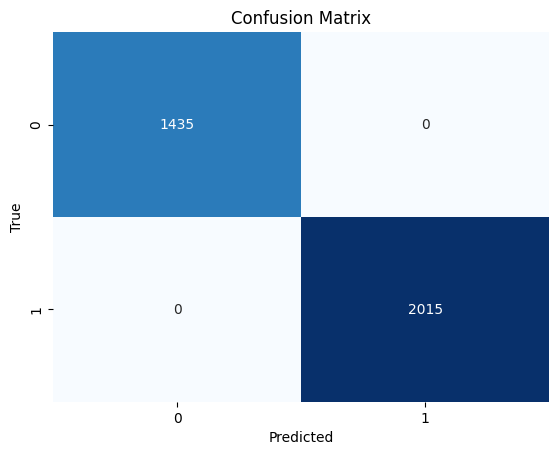

In [11]:
######################################################################
# 10. Full evaluation  ───────────────────────────────────────────────
######################################################################
y_true=y_pred=[]
with torch.no_grad():
    for x,lbl,cid,_ in test_loader:
        x,cid = x.to(device), cid.to(device)
        recon,_,_ = model(x,cid)
        score = torch.mean((x-recon)**2).item()
        pred  = 1 if score>THRESH[cid.item()] else 0
        y_true.append(lbl.item()); y_pred.append(pred)

print(classification_report(y_true,y_pred, target_names=["Normal","Anomaly"]))

cm = confusion_matrix(y_true,y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix"); plt.show()


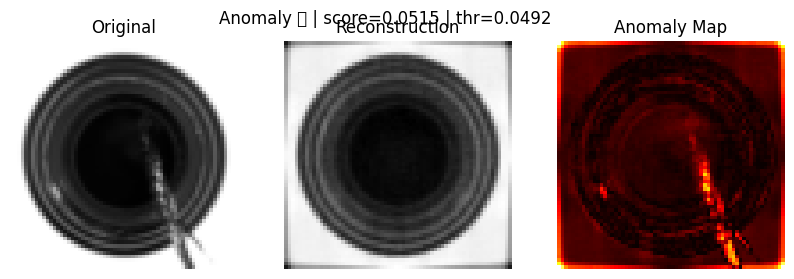

In [12]:

######################################################################
# 11. Quick visual inspection helper  ────────────────────────────────
######################################################################
from pathlib import Path
def _extract_path(s):
    for e in s:
        if isinstance(e,(str,Path)) and os.sep in str(e): return str(e)
    raise TypeError

def get_first_anomaly_path(ds, kw=None):
    for smp in ds.samples:
        p = _extract_path(smp).lower()
        if kw:
            if any(k.lower() in p for k in kw): return p
        elif "good" not in p: return p
    raise ValueError

def inspect(path):
    model.eval()
    img = default_loader(path)
    x = tfm_test(img).unsqueeze(0).to(device)
    cid_name = [c for c in train_ds.classes if c in path][0]
    cid = torch.tensor([train_ds.cls2idx[cid_name]]).to(device)
    with torch.no_grad():
        recon,_,_ = model(x,cid)
    score = torch.mean((x-recon)**2).item()
    pred  = "Anomaly 🚨" if score>THRESH[cid.item()] else "Normal ✅"
    orig = ((x.squeeze().cpu().numpy()*0.5)+0.5)
    rec  = ((recon.squeeze().cpu().numpy()*0.5)+0.5)
    amap = np.abs(orig-rec)
    plt.figure(figsize=(10,3))
    for i,(im,t) in enumerate(zip([orig,rec,amap],["Original","Reconstruction","Anomaly Map"])):
        plt.subplot(1,3,i+1); plt.imshow(im, cmap="gray" if i<2 else "hot"); plt.axis("off"); plt.title(t)
    plt.suptitle(f"{pred} | score={score:.4f} | thr={THRESH[cid.item()]:.4f}"); plt.show()

example = get_first_anomaly_path(test_ds)
inspect(example)

In [13]:
######################################################################
# 12. Save artefacts  ────────────────────────────────────────────────
######################################################################
torch.save(model.state_dict(), "vae_q_model.pth")
np.save("thresholds.npy", THRESH)
with open("class_to_idx.json","w") as f: json.dump(train_ds.cls2idx,f)
print("Model & thresholds saved.")

Model & thresholds saved.
